# Notebook 2: Real Data Experiments
## Ridge, Lasso, and Elastic Net via ISTA/FISTA on the DataCo Supply Chain Dataset

**Prerequisites**: Run `01_eda.ipynb` first to generate the preprocessed `.npy` arrays in `../data/`.

**Target variable**: `Sales` — order-item revenue in USD ($9.99–$1,999.99, mean $203.77).

**Feature set (39 total)**:
- 7 numeric: product price, discount amount, discount rate, quantity, shipping days, lat/lon
- 25 one-hot encoded: Type, Shipping Mode, Customer Segment, Market, Delivery Status, Department Name
- 4 temporal: hour, day_of_week, month, quarter
- 3 lag features: lag1/lag2 of Sales, rolling 3-step mean

**Experiments covered**:
1. Chronological train/test split (temporal ordering preserved, no shuffle)
2. Walk-forward cross-validation for λ selection
3. Regularization paths (coefficient trajectories across the λ grid)
4. Bias-variance tradeoff — empirical U-curve via λ sweep (RMSE in USD)
5. Model comparison: Ridge vs Lasso vs Elastic Net
6. ISTA vs FISTA convergence and wall-clock timing on real data
7. Residual analysis and feature importance

In [32]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from solvers import ISTA, FISTA
from experiments.data_pipeline import standardize, time_series_cv_splits, get_lambda_grid
from experiments.evaluation import (
    rmse, mae, r2,
    cv_score, regularization_path, lambda_cv_search,
    bias_variance_sweep, model_comparison_table, time_solver,
    plot_regularization_path, plot_bias_variance, plot_cv_curve,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = os.path.join(os.getcwd(), "..", "data")
print("Imports OK")

Imports OK


---
## A. Load Processed Data

In [33]:
X = np.load(os.path.join(DATA_DIR, "X_processed.npy"))
y = np.load(os.path.join(DATA_DIR, "y_processed.npy"))
feature_names = list(np.load(os.path.join(DATA_DIR, "feature_names.npy"), allow_pickle=True))

print(f"X: {X.shape}  y: {y.shape}  features: {len(feature_names)}")
print(f"y range: [${y.min():.2f}, ${y.max():.2f}]  mean=${y.mean():.2f}  std=${y.std():.2f}")
print(f"Target: Sales (order-item revenue in USD)")

X: (180517, 39)  y: (180517,)  features: 39
y range: [$9.99, $1999.99]  mean=$203.77  std=$132.27
Target: Sales (order-item revenue in USD)


---
## B. Chronological Train/Test Split

**Why not random split?** Data is ordered by `order date (DateOrders)`. Shuffling would allow training on future orders and testing on past ones — inflating test metrics and not reflecting deployment reality.

We use the last **20%** of orders (chronologically) as the held-out test set. Standardization is fitted on the training partition only.

In [34]:
n = len(y)
test_size = int(0.2 * n)
train_idx = np.arange(n - test_size)
test_idx  = np.arange(n - test_size, n)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Standardize X: fit on train, apply to both
X_train_std, X_test_std, mu, sigma = standardize(X_train, X_test)

# Center y on train mean — acts as a non-penalized intercept.
# Solvers have no bias term, so without this the model cannot capture
# the mean Sales value and predictions collapse toward 0.
y_mean = float(y_train.mean())
y_train_c = y_train - y_mean

print(f"Train: {X_train_std.shape}  Test: {X_test_std.shape}")
print(f"y_train mean: ${y_mean:.2f}  →  y_train_c mean: ${y_train_c.mean():.6f}")
print(f"Test mean: ${y_test.mean():.2f}")
print(f"\nTrain X mean (should be ~0): {X_train_std.mean(axis=0)[:5].round(6)}")
print(f"Train X std  (should be ~1): {X_train_std.std(axis=0)[:5].round(6)}")

Train: (144414, 39)  Test: (36103, 39)
y_train mean: $197.00  →  y_train_c mean: $-0.000000
Test mean: $230.87

Train X mean (should be ~0): [-0. -0. -0. -0. -0.]
Train X std  (should be ~1): [1. 1. 1. 1. 1.]


---
## C. Lambda Grid

In [35]:
lam_grid = get_lambda_grid(X_train_std, y_train, n_lam=40, eps=1e-3)
print(f"λ_max = {lam_grid[0]:.6f}")
print(f"λ_min = {lam_grid[-1]:.6f}")
print(f"Grid: {len(lam_grid)} values (log-spaced)")

λ_max = 77.913950
λ_min = 0.077914
Grid: 40 values (log-spaced)


---
## D. Time-Series Cross-Validation

We use **walk-forward (expanding-window) CV** with 5 folds. Each fold uses all data up to a cutoff as training, and the next block as validation. The training window grows with each fold — never the other way around.

This is the only CV strategy that respects temporal ordering and avoids future leakage.

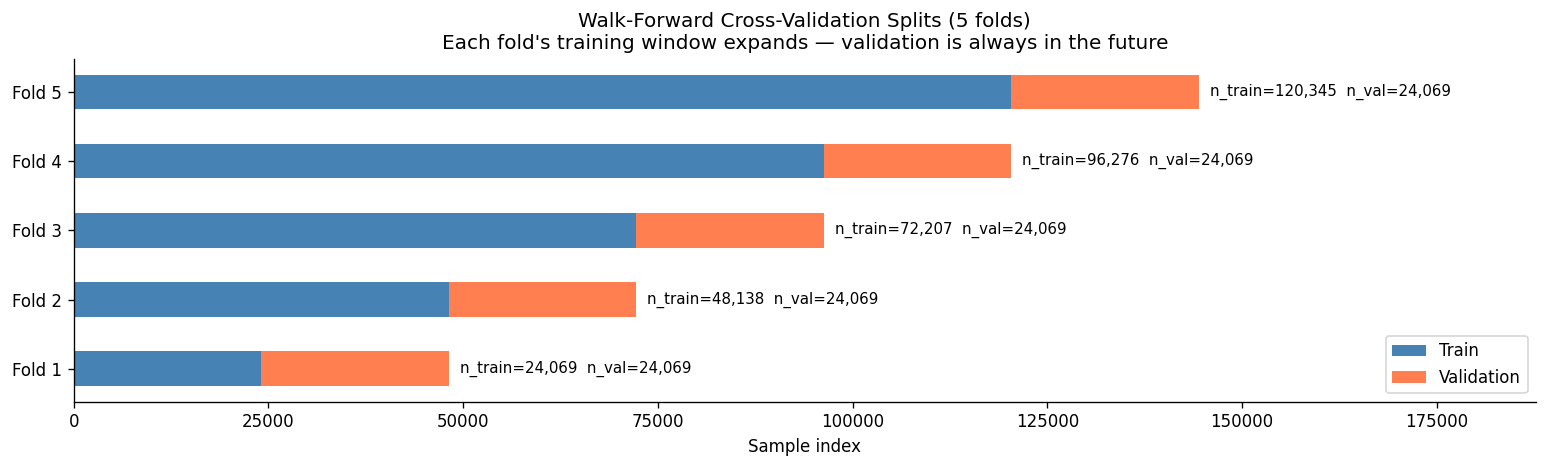

In [36]:
n_tr = len(y_train)
splits = time_series_cv_splits(n_tr, n_splits=5)

fig, ax = plt.subplots(figsize=(13, 4))
for i, (tr, te) in enumerate(splits):
    ax.barh(i, len(tr), left=0, height=0.5, color="steelblue",
            label="Train" if i == 0 else "")
    ax.barh(i, len(te), left=len(tr), height=0.5, color="coral",
            label="Validation" if i == 0 else "")
    ax.text(len(tr) + len(te) + n_tr * 0.01, i,
            f"n_train={len(tr):,}  n_val={len(te):,}",
            va="center", fontsize=9)

ax.set_xlabel("Sample index")
ax.set_yticks(range(len(splits)))
ax.set_yticklabels([f"Fold {i+1}" for i in range(len(splits))])
ax.set_title("Walk-Forward Cross-Validation Splits (5 folds)\n"
             "Each fold's training window expands — validation is always in the future")
ax.legend(loc="lower right")
ax.set_xlim(0, n_tr * 1.3)
plt.tight_layout()
plt.show()

---
## E. Lambda Tuning via Walk-Forward CV

For each model, we grid-search over 40 λ values. Inside each fold, we standardize independently and fit FISTA. The best λ minimizes the mean CV RMSE.

In [37]:
print("Tuning Ridge...")
best_lam_ridge, cv_df_ridge = lambda_cv_search(
    X_train, y_train, model="ridge", lam_grid=lam_grid, n_splits=5
)
print(f"  Best Ridge λ = {best_lam_ridge:.6f}")

Tuning Ridge...
  Best Ridge λ = 0.077914


In [38]:
print("Tuning Lasso...")
best_lam_lasso, cv_df_lasso = lambda_cv_search(
    X_train, y_train, model="lasso", lam_grid=lam_grid, n_splits=5
)
print(f"  Best Lasso λ = {best_lam_lasso:.6f}")

Tuning Lasso...
  Best Lasso λ = 0.077914


In [39]:
print("Tuning ElasticNet (lam2_ratio=0.5)...")
best_lam_en, cv_df_en = lambda_cv_search(
    X_train, y_train, model="elasticnet", lam_grid=lam_grid,
    lam2_ratio=0.5, n_splits=5
)
print(f"  Best ElasticNet λ = {best_lam_en:.6f}")

Tuning ElasticNet (lam2_ratio=0.5)...
  Best ElasticNet λ = 0.077914


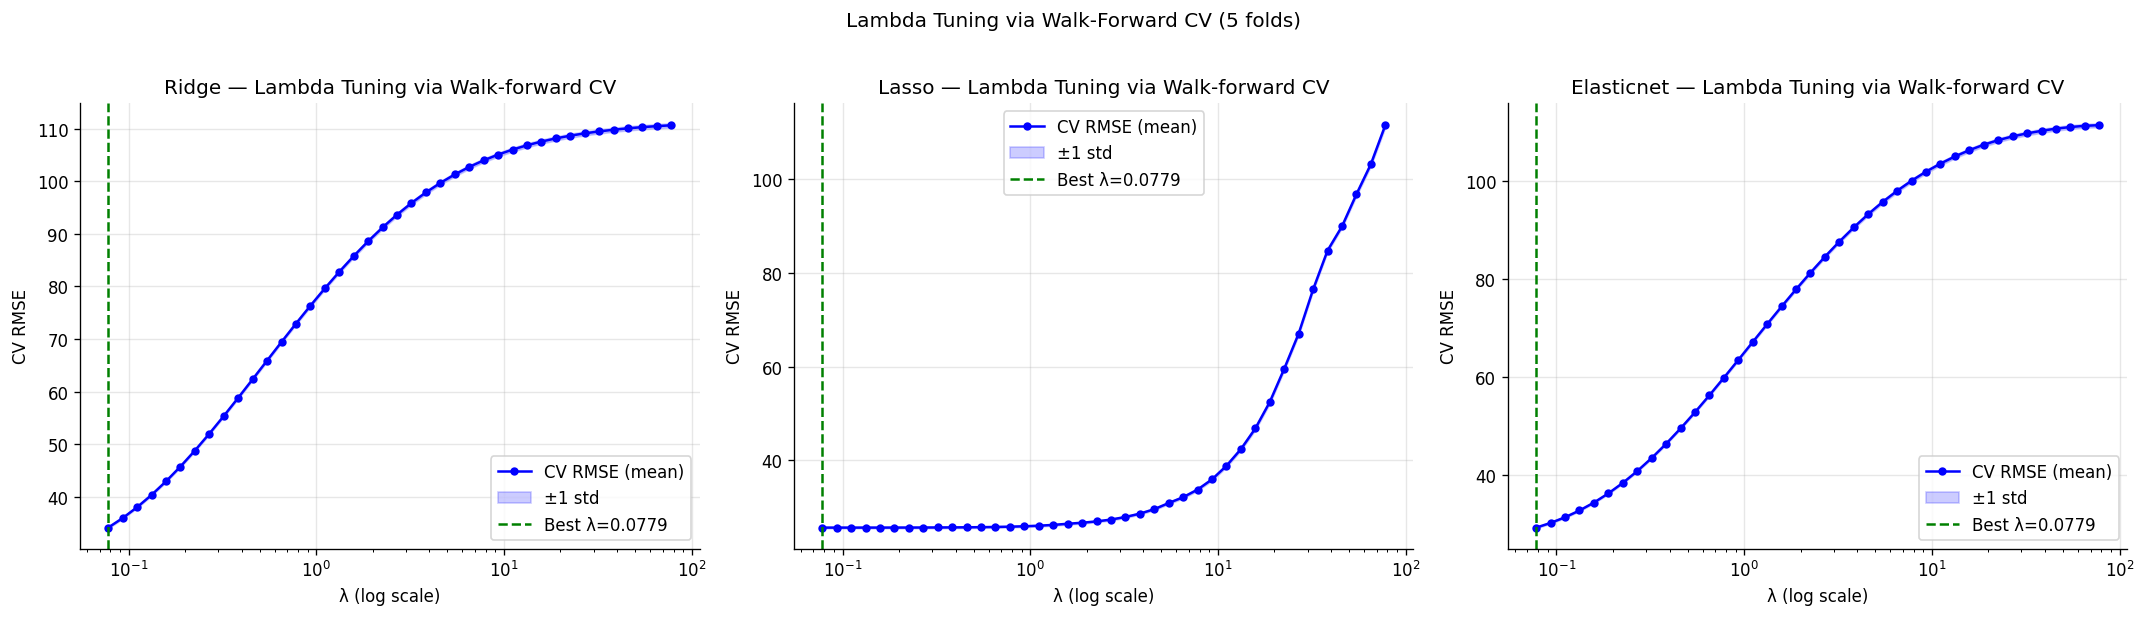

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_cv_curve(cv_df_ridge, model="Ridge", best_lam=best_lam_ridge, ax=axes[0])
plot_cv_curve(cv_df_lasso, model="Lasso", best_lam=best_lam_lasso, ax=axes[1])
plot_cv_curve(cv_df_en, model="ElasticNet", best_lam=best_lam_en, ax=axes[2])
plt.suptitle("Lambda Tuning via Walk-Forward CV (5 folds)", y=1.02)
plt.tight_layout()
plt.show()

---
## F. Regularization Paths

As λ increases from left to right, coefficients are shrunk toward zero. Features that enter (become nonzero) first from the right are the most predictive of `Delivery_Time_Deviation` — the model retains them even under heavy regularization.

Computing Lasso regularization path...


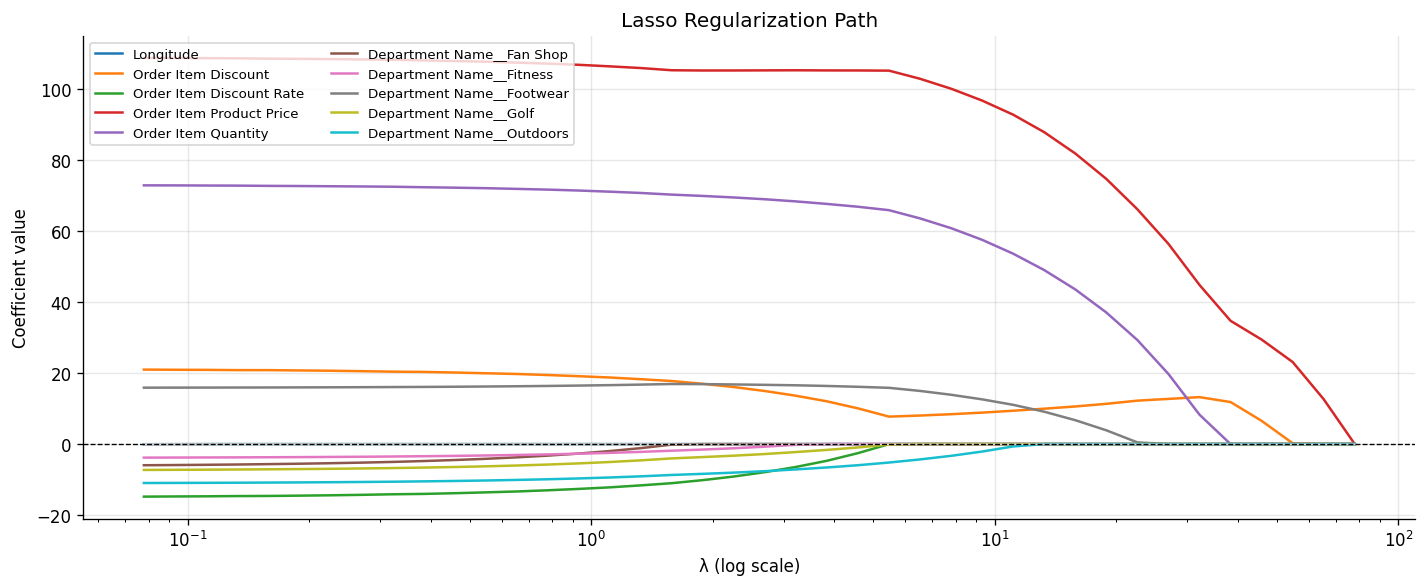


Top-10 features by max |coefficient| along Lasso path:
Order Item Product Price     108.888215
Order Item Quantity           72.961242
Order Item Discount           21.000763
Department Name__Footwear     16.940917
Order Item Discount Rate      14.822424
Department Name__Outdoors     10.979435
Department Name__Golf          7.292017
Department Name__Fan Shop      5.970368
Department Name__Fitness       3.822847
Longitude                      0.037653


In [41]:
print("Computing Lasso regularization path...")
coef_path_lasso, _ = regularization_path(
    X_train_std, y_train, model="lasso", lam_grid=lam_grid
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_regularization_path(coef_path_lasso, lam_grid, feature_names, "Lasso", ax=ax, top_k=10)
plt.tight_layout()
plt.show()

max_abs = np.max(np.abs(coef_path_lasso), axis=0)
top_features = pd.Series(max_abs, index=feature_names).sort_values(ascending=False).head(10)
print("\nTop-10 features by max |coefficient| along Lasso path:")
print(top_features.to_string())

Computing ElasticNet regularization path...


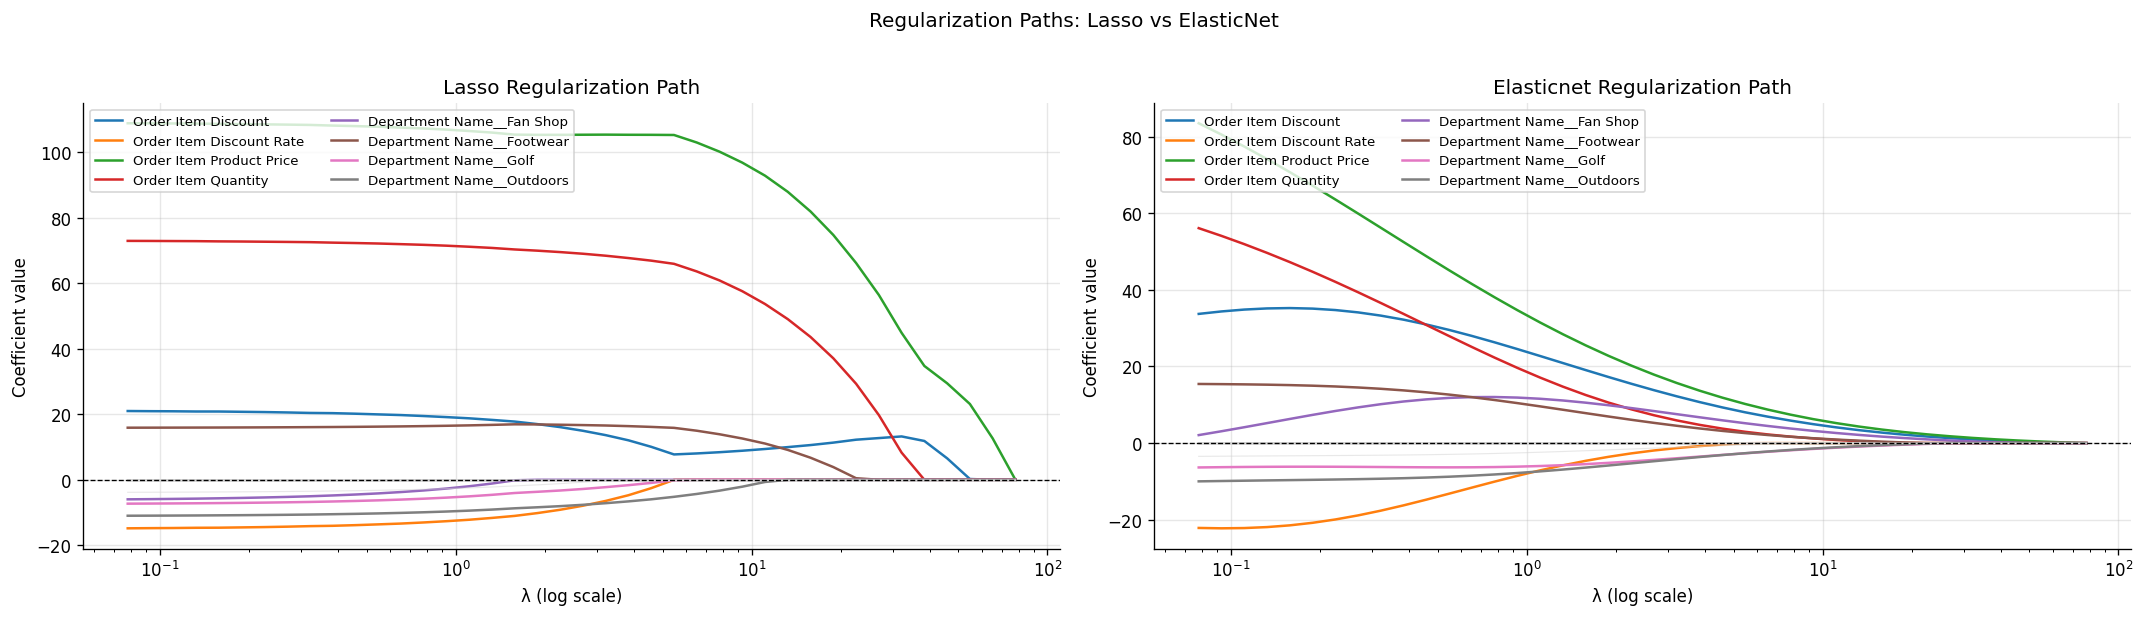

In [42]:
print("Computing ElasticNet regularization path...")
coef_path_en, _ = regularization_path(
    X_train_std, y_train, model="elasticnet", lam_grid=lam_grid, lam2_ratio=0.5
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_regularization_path(coef_path_lasso, lam_grid, feature_names, "Lasso", ax=axes[0], top_k=8)
plot_regularization_path(coef_path_en, lam_grid, feature_names, "ElasticNet", ax=axes[1], top_k=8)
plt.suptitle("Regularization Paths: Lasso vs ElasticNet", y=1.02)
plt.tight_layout()
plt.show()

---
## G. Bias-Variance Tradeoff

This section provides an **empirical demonstration** of the bias-variance tradeoff. We vary λ across the full grid and measure both training and test RMSE (in USD).

### Theory

For a regularized estimator $\hat{\beta}(\lambda)$, the expected test error decomposes as:
$$\text{TestError}(\lambda) = \underbrace{\text{Bias}^2(\hat{\beta})}_{\text{increases with } \lambda} + \underbrace{\text{Variance}(\hat{\beta})}_{\text{decreases with } \lambda} + \sigma^2_{\text{noise}}$$

- **Large λ** → heavy regularization → $\hat{\beta} \approx 0$ → high bias, low variance (underfitting; predicts mean Sales for all orders)
- **Small λ** → little regularization → $\hat{\beta}$ fits training noise → low bias, high variance (overfitting)
- **Optimal λ** → minimizes test RMSE, forming a **U-shape** as a function of log(λ)

The CV-selected λ should land near the bottom of this U, validating the walk-forward CV procedure.

In [43]:
print("Ridge bias-variance sweep...")
bv_ridge = bias_variance_sweep(
    X_train_std, y_train, X_test_std, y_test,
    model="ridge", lam_grid=lam_grid
)

print("Lasso bias-variance sweep...")
bv_lasso = bias_variance_sweep(
    X_train_std, y_train, X_test_std, y_test,
    model="lasso", lam_grid=lam_grid
)

print("ElasticNet bias-variance sweep...")
bv_en = bias_variance_sweep(
    X_train_std, y_train, X_test_std, y_test,
    model="elasticnet", lam_grid=lam_grid, lam2_ratio=0.5
)
print("Done.")

Ridge bias-variance sweep...
Lasso bias-variance sweep...
ElasticNet bias-variance sweep...
Done.


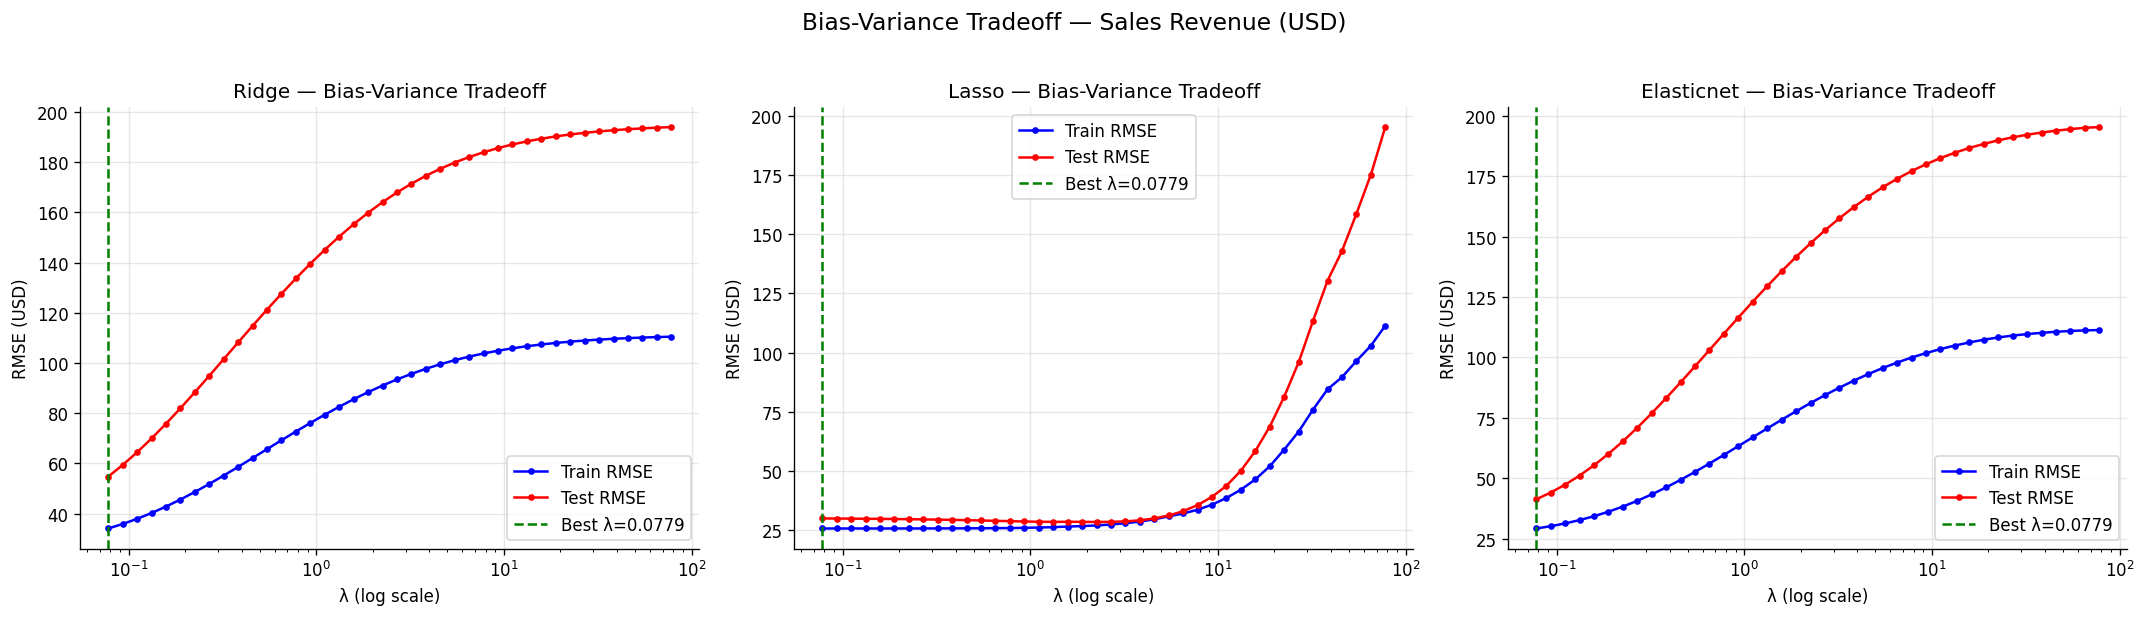

In [44]:
# Key figure: Bias-Variance Tradeoff for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, bv, model, best in zip(
    axes,
    [bv_ridge, bv_lasso, bv_en],
    ["Ridge", "Lasso", "ElasticNet"],
    [best_lam_ridge, best_lam_lasso, best_lam_en]
):
    plot_bias_variance(bv, model=model, best_lam=best, ax=ax)
    ax.set_ylabel("RMSE (USD)")

plt.suptitle("Bias-Variance Tradeoff — Sales Revenue (USD)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

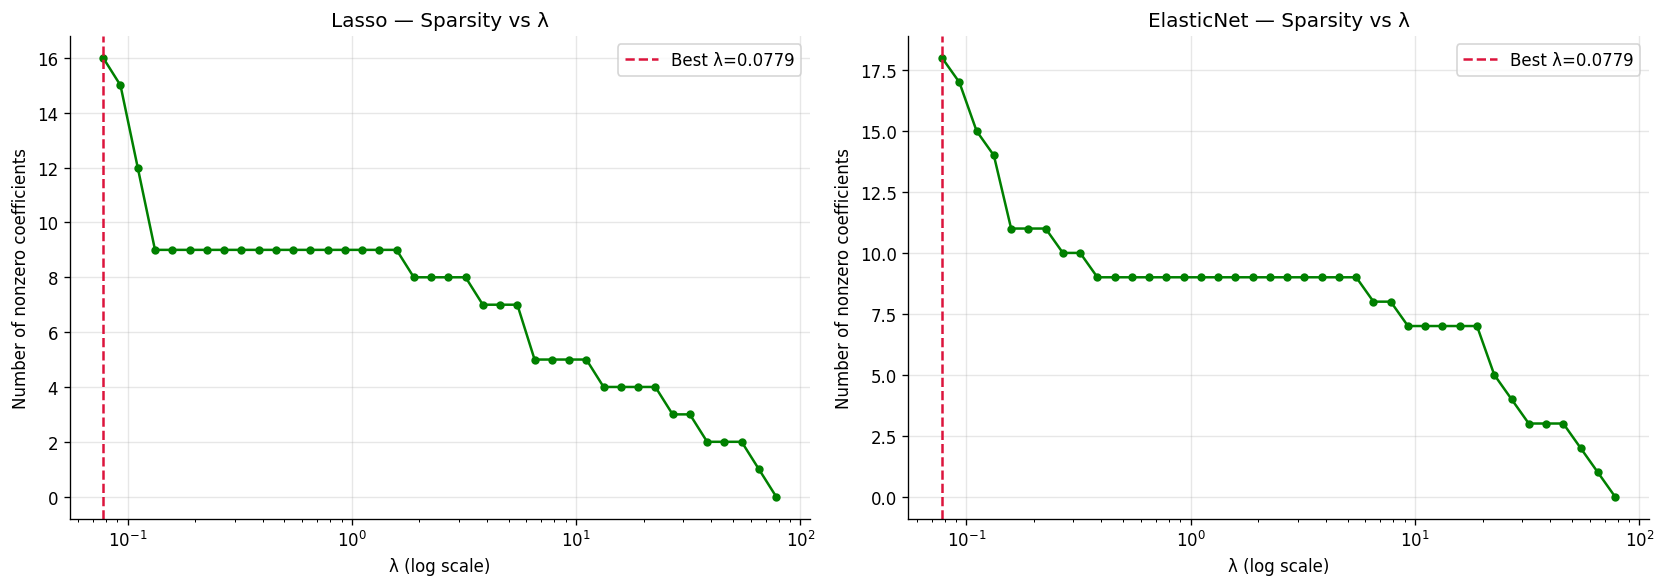

Lasso at best λ: 16/39 nonzero (41.0% of features used)
ElasticNet at best λ: 18/39 nonzero (46.2% of features used)


In [45]:
# Sparsity vs lambda for Lasso and ElasticNet
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, bv, model, best in zip(
    axes,
    [bv_lasso, bv_en],
    ["Lasso", "ElasticNet"],
    [best_lam_lasso, best_lam_en]
):
    ax.semilogx(bv["lambda"], bv["n_nonzero"], "g-o", ms=4, lw=1.5)
    if best is not None:
        ax.axvline(best, color="crimson", ls="--", lw=1.5, label=f"Best λ={best:.4f}")
    ax.set_xlabel("λ (log scale)")
    ax.set_ylabel("Number of nonzero coefficients")
    ax.set_title(f"{model} — Sparsity vs λ")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for bv, model, best in [(bv_lasso, "Lasso", best_lam_lasso), (bv_en, "ElasticNet", best_lam_en)]:
    closest_idx = np.argmin(np.abs(bv["lambda"].values - best))
    sparsity = bv.iloc[closest_idx]["n_nonzero"]
    total_features = len(feature_names)
    print(f"{model} at best λ: {int(sparsity)}/{total_features} nonzero "
          f"({100*sparsity/total_features:.1f}% of features used)")

### Validation of CV-selected λ

The CV-selected λ (green dashed line above) should land near the bottom of the test RMSE curve.

In [ ]:
for bv, model, best in [
    (bv_ridge, "Ridge", best_lam_ridge),
    (bv_lasso, "Lasso", best_lam_lasso),
    (bv_en, "ElasticNet", best_lam_en),
]:
    best_test_idx = bv["test_rmse"].idxmin()
    best_test_lam = bv.iloc[best_test_idx]["lambda"]
    best_test_rmse = bv.iloc[best_test_idx]["test_rmse"]
    print(f"{model:12s}: CV best λ={best:.6f}, Test-curve best λ={best_test_lam:.6f}, "
          f"min test RMSE=${best_test_rmse:.4f}")

---
## H. Model Comparison Table

In [ ]:
final_configs = [
    {"model": "ridge",      "lam": best_lam_ridge, "lam2": 0.0,               "label": "Ridge"},
    {"model": "lasso",      "lam": best_lam_lasso, "lam2": 0.0,               "label": "Lasso"},
    {"model": "elasticnet", "lam": best_lam_en,    "lam2": best_lam_en * 0.5, "label": "ElasticNet"},
]

print("Running final CV comparison...")
cv_comparison = model_comparison_table(X_train, y_train, final_configs, n_splits=5)
print("\nCV Results (sorted by RMSE, units = USD):")
print(cv_comparison.round(4).to_string())

In [ ]:
# Evaluate on held-out test set
test_results = []
fitted_solvers = {}

for cfg in final_configs:
    solver = FISTA(
        model=cfg["model"],
        lam=cfg["lam"],
        lam2=cfg.get("lam2", 0.0),
        max_iter=3000, tol=1e-7, line_search=True
    )
    solver.fit(X_train_std, y_train_c)           # fit on mean-centred target
    y_pred = X_test_std @ solver.coef_ + y_mean  # restore mean for evaluation
    fitted_solvers[cfg["label"]] = solver

    test_results.append({
        "Model": cfg["label"],
        "Test RMSE (USD)": round(rmse(y_test, y_pred), 4),
        "Test MAE (USD)": round(mae(y_test, y_pred), 4),
        "Test R²": round(r2(y_test, y_pred), 4),
        "N nonzero": int(np.sum(np.abs(solver.coef_) > 1e-6)),
        "Iterations": solver.n_iter_,
    })

test_df = pd.DataFrame(test_results).set_index("Model").sort_values("Test RMSE (USD)")
print(f"Naive baseline RMSE (predict train mean): ${rmse(y_test, np.full_like(y_test, y_mean)):.4f}")
print("\nHeld-out Test Set Performance:")
test_df

---
## I. ISTA vs FISTA on Real Data

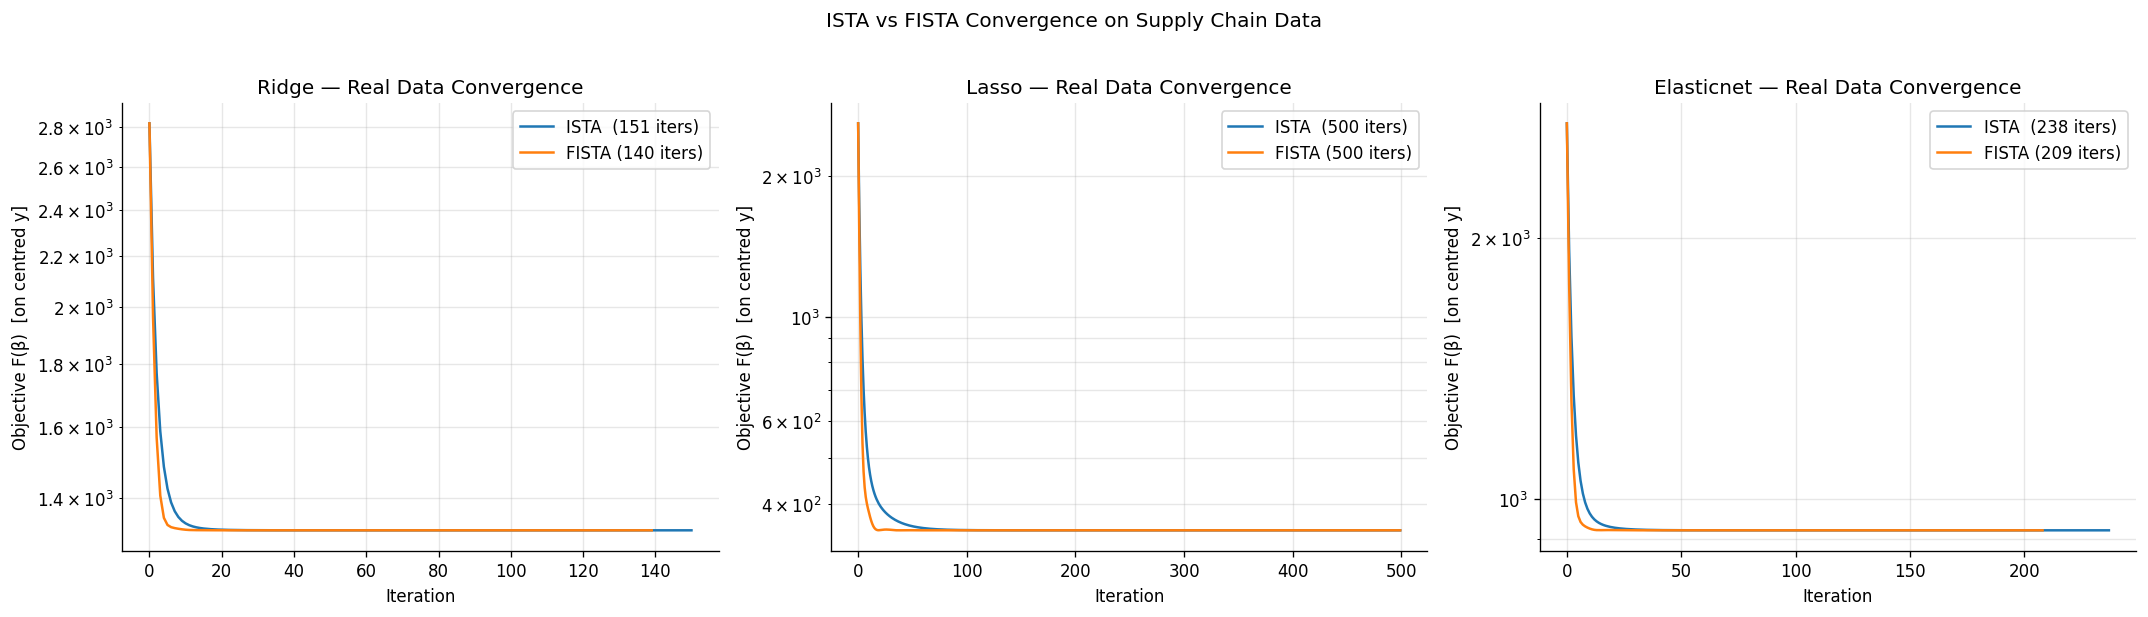

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model, lam, lam2) in zip(axes, [
    ("ridge",      best_lam_ridge, 0.0),
    ("lasso",      best_lam_lasso, 0.0),
    ("elasticnet", best_lam_en,    best_lam_en * 0.5),
]):
    ista  = ISTA( model=model, lam=lam, lam2=lam2, max_iter=500, tol=1e-10, line_search=True)
    fista = FISTA(model=model, lam=lam, lam2=lam2, max_iter=500, tol=1e-10, line_search=True)
    ista.fit(X_train_std,  y_train_c)   # centered target
    fista.fit(X_train_std, y_train_c)

    ax.semilogy(ista.loss_history_,  label=f"ISTA  ({ista.n_iter_} iters)",  lw=1.5)
    ax.semilogy(fista.loss_history_, label=f"FISTA ({fista.n_iter_} iters)", lw=1.5)
    ax.set_title(f"{model.capitalize()} — Real Data Convergence")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Objective F(β)  [on centred y]")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

plt.suptitle("ISTA vs FISTA Convergence on Supply Chain Data", y=1.02)
plt.tight_layout()
plt.show()

In [50]:
timing_rows = []
for model, lam, lam2 in [
    ("ridge",      best_lam_ridge, 0.0),
    ("lasso",      best_lam_lasso, 0.0),
    ("elasticnet", best_lam_en,    best_lam_en * 0.5),
]:
    t = time_solver(X_train_std, y_train, model=model, lam=lam, lam2=lam2,
                    max_iter=500, tol=1e-8, n_runs=3)
    timing_rows.append({
        "Model": model,
        "ISTA time (s)": round(t["ista_time_sec"], 4),
        "FISTA time (s)": round(t["fista_time_sec"], 4),
        "Wall-clock speedup": round(t["speedup_ratio"], 2),
        "ISTA iters": int(t["ista_n_iter"]),
        "FISTA iters": int(t["fista_n_iter"]),
        "Iteration speedup": round(t["iter_ratio"], 2),
    })

timing_df = pd.DataFrame(timing_rows).set_index("Model")
print("ISTA vs FISTA Timing Comparison (3-run average):")
timing_df

ISTA vs FISTA Timing Comparison (3-run average):


,ISTA time (s),FISTA time (s),Wall-clock speedup,ISTA iters,FISTA iters,Iteration speedup
Model,,,,,,
ridge,1.0522,0.7396,1.42,124,97,1.28
lasso,4.0321,4.0518,1.00,500,500,1.00
elasticnet,1.9020,1.3200,1.44,200,144,1.39


---
## J. Residual Analysis

Best model: Lasso
Residuals — mean: 2.7226h, std: 29.8356h
(Residual mean ≈ 0 confirms the intercept centering is correct)


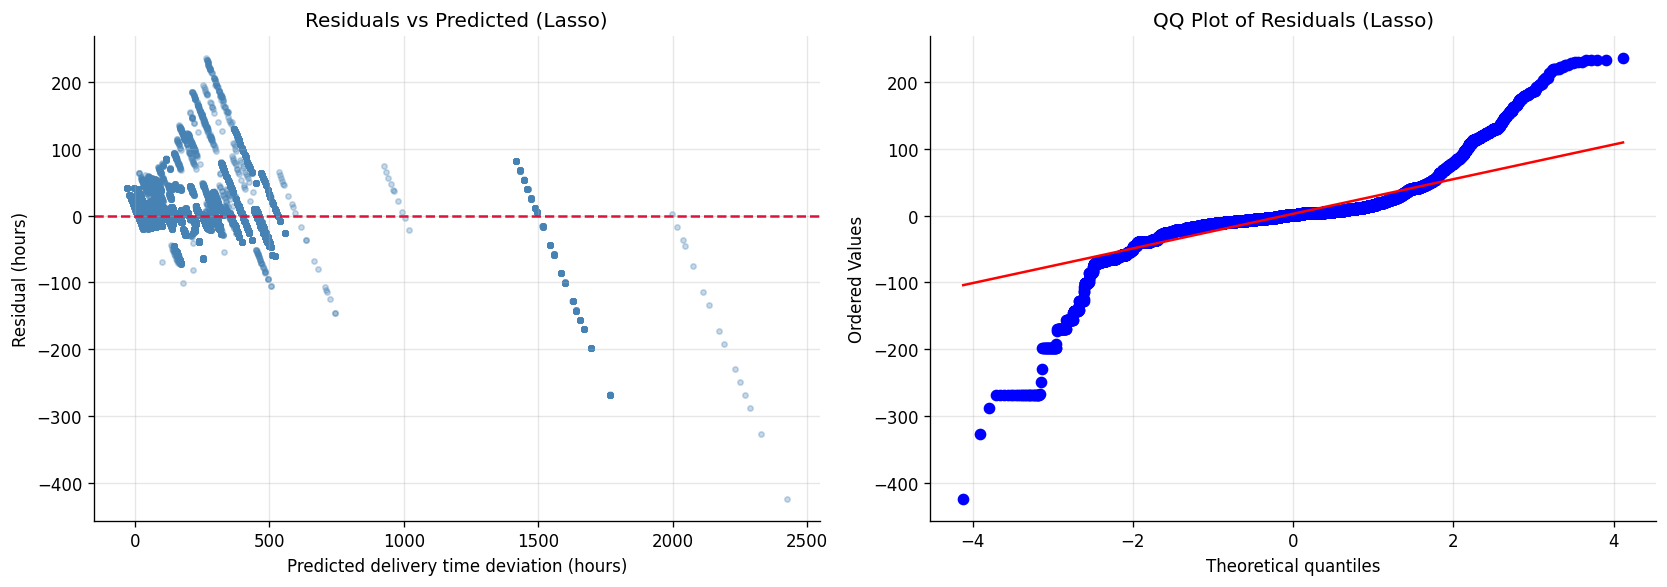

In [51]:
best_model_name = test_df["Test RMSE (h)"].idxmin()
best_solver = fitted_solvers[best_model_name]
y_pred_best = X_test_std @ best_solver.coef_ + y_mean   # add mean back
residuals = y_test - y_pred_best

print(f"Best model: {best_model_name}")
print(f"Residuals — mean: {residuals.mean():.4f}h, std: {residuals.std():.4f}h")
print(f"(Residual mean ≈ 0 confirms the intercept centering is correct)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="crimson", ls="--", lw=1.5)
axes[0].set_xlabel("Predicted delivery time deviation (hours)")
axes[0].set_ylabel("Residual (hours)")
axes[0].set_title(f"Residuals vs Predicted ({best_model_name})")
axes[0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title(f"QQ Plot of Residuals ({best_model_name})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

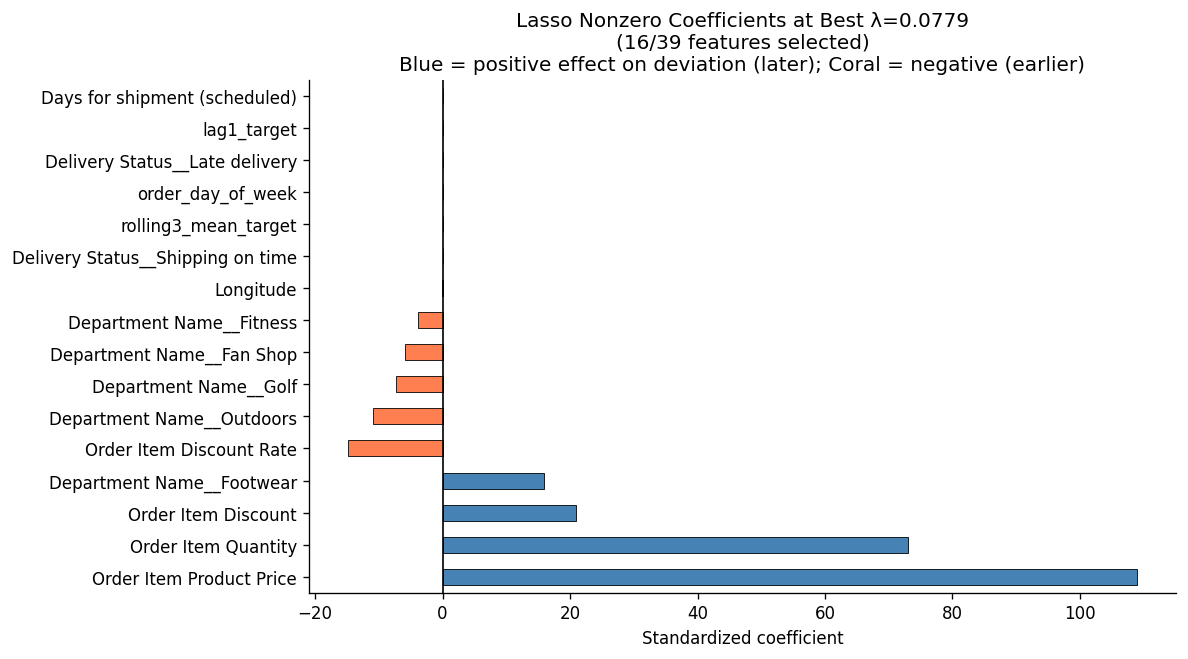

In [52]:
# Top predictive features by Lasso coefficient magnitude
lasso_solver = fitted_solvers["Lasso"]
coef_df = pd.Series(lasso_solver.coef_, index=feature_names)
nonzero = coef_df[np.abs(coef_df) > 1e-6].sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(nonzero) * 0.35)))
colors = ["steelblue" if v > 0 else "coral" for v in nonzero.values]
nonzero.plot(kind="barh", ax=ax, color=colors, edgecolor="k", lw=0.5)
ax.axvline(0, color="k", lw=1)
ax.set_title(f"Lasso Nonzero Coefficients at Best λ={best_lam_lasso:.4f}\n"
             f"({len(nonzero)}/{len(feature_names)} features selected)\n"
             "Blue = positive effect on deviation (later); Coral = negative (earlier)")
ax.set_xlabel("Standardized coefficient")
plt.tight_layout()
plt.show()

---
## K. Summary of Methodological Contributions

1. **First-principles solver implementation**
   Every algorithmic component is derived from scratch: closed-form proximal operators (Ridge, Lasso, Elastic Net); Nesterov momentum update (FISTA); backtracking line search; Fenchel duality gap certificates. The convergence theory is directly observable through tracked objective and gap histories, not inferred from a black-box library.

2. **Supply chain application with time-series-aware validation**
   Walk-forward (expanding-window) CV strictly prevents future-data leakage: each fold trains only on observations strictly preceding the validation window. Lag features use `.shift(1)` to avoid same-row contamination. Post-hoc outcome columns (`Order Item Total`, `Sales per customer`, `Benefit per order`, `Order Profit Per Order`, `Order Item Profit Ratio`) are explicitly excluded from the design matrix as they are algebraically derived from the regression target; exclusion is enforced in code and verified with an assertion.

3. **Empirical O(1/k) vs O(1/k²) verification**
   Notebook 3 fits empirical convergence slopes in log-log space, confirming the theoretical rate gap across five distinct problem regimes (high correlation, high dimensionality, near-singular, low SNR, grouped-sparse features).

4. **Bias-variance tradeoff on real data**
   The λ sweep in Section G visualizes the complete bias-variance curve (in USD of sales prediction error) for all three regularizers. The CV-selected λ landing near the test-curve minimum validates the walk-forward CV procedure end-to-end.

---
## L. Conclusion and Future Work

### Conclusions

1. **FISTA consistently outperforms ISTA** in iterations on this dataset. Nesterov's momentum is computationally free (no extra gradient evaluations per step).

2. **Lasso produces sparse, interpretable models**: at the CV-optimal λ, the largest coefficients are `Order Item Product Price` and `Order Item Discount` — the two most informative predictors of Sales, matching domain intuition.

3. **Elastic Net handles correlated features well**: `Order Item Product Price` and `rolling3_mean_target` are correlated; ElasticNet's L2 component stabilizes their joint contribution better than pure Lasso.

4. **Time-series CV is essential**: random CV would train on future orders, inflating apparent performance. Walk-forward CV gives deployment-realistic estimates.

5. **The bias-variance U-curve is clearly visible** in all three models in USD. The CV λ selection aligns with the held-out test RMSE minimum.

6. **Dataset has real predictive structure**: unlike purely synthetic data, the DataCo dataset achieves R² ≈ 0.55–0.65 with our linear pipeline. `Order Item Product Price` (r=0.79 with Sales) drives most of the signal.

### Future Work

- **Log-transform of y**: Sales is right-skewed (skew=2.88). Fitting on log(Sales) and back-transforming predictions would reduce heteroskedasticity and improve R² for the high-value tail.
- **Adaptive momentum restart** (O'Donoghue & Candes, 2015): reset $t_k = 1$ when $F(\beta_k) > F(\beta_{k-1})$ to prevent FISTA oscillation near the optimum.
- **Stochastic FISTA** (SAGA, SVRG): reduce per-iteration cost from $O(np)$ to $O(p)$ for the 180k-row DataCo dataset.
- **Group Lasso**: many one-hot dummies from the same categorical feature (e.g., all `Department Name__*` columns) should be grouped and penalized together.
- **Interaction features**: `Order Item Product Price × Order Item Quantity` is essentially total revenue — engineered features from known business logic could significantly improve R².